# Type I Errors, Type II Errors, and Statistical Power

## Learning Objectives

By the end of this notebook you will be able to:

1. Define **Type I error** ($\alpha$) and **Type II error** ($\beta$) and explain their consequences.
2. Explain the **tradeoff** between $\alpha$ and $\beta$ — why you cannot minimise both simultaneously.
3. Define **statistical power** ($1 - \beta$) and explain the four factors that determine it.
4. Derive the **power formula** for a one-sample z-test from first principles.
5. Implement `power_z_test()` from scratch and plot **power curves**.
6. Perform a **sample size calculation** — given desired power, effect size, $\alpha$, and $\sigma$, determine how many observations you need.
7. Compute and interpret **Cohen's $d$** as a standardised effect size.

## Prerequisites

- [01_hypothesis_framework.ipynb](01_hypothesis_framework.ipynb) — Null/alternative hypotheses, test statistics, p-values, significance level
- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — Normal distribution, CDF
- [Module 04](../04_estimation/04_confidence_intervals.ipynb) — Sampling distributions, standard error

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Two Kinds of Mistakes

In [notebook 01](01_hypothesis_framework.ipynb) we set up hypothesis testing as a binary decision: given data, we either **reject** $H_0$ or **fail to reject** $H_0$. Any binary decision procedure can make two kinds of mistakes:

|                          | $H_0$ is actually **true** | $H_0$ is actually **false**    |
|--------------------------|----------------------------|--------------------------------|
| **Reject** $H_0$         | Type I error ($\alpha$)    | Correct! (Power = $1 - \beta$) |
| **Fail to reject** $H_0$ | Correct!                   | Type II error ($\beta$)        |

This 2$\times$2 table is the foundation of everything in this notebook. Let's examine each cell carefully.

---

## 2. Type I Error: False Alarms ($\alpha$)

> **Definition.** A **Type I error** occurs when we reject $H_0$ even though $H_0$ is true. The probability of a Type I error is:
>
> $$\alpha = P(\text{reject } H_0 \mid H_0 \text{ is true})$$

This is the **false positive rate** — concluding there is an effect when there isn't one.

### The fire alarm analogy

Think of a fire alarm in a building:

- $H_0$: There is no fire.
- $H_1$: There is a fire.
- The alarm sounds (reject $H_0$) or stays silent (fail to reject $H_0$).

A **Type I error is a false alarm** — the alarm screams, everyone evacuates, but there's no fire. It's a nuisance. You wasted time, caused panic, and if it happens too often, people start ignoring the alarm entirely (the "boy who cried wolf" problem).

### Why $\alpha$ is easy to control

Here's the good news: **you choose $\alpha$ directly** when you set the significance level. If you test at $\alpha = 0.05$, you are guaranteeing that when $H_0$ is true, you'll make a Type I error at most 5% of the time. Want fewer false alarms? Set $\alpha = 0.01$. The significance level *is* the Type I error rate — by definition.

We verified this in notebook 01 (Section 7): when $H_0$ is true, p-values are $\text{Uniform}(0, 1)$, so exactly a fraction $\alpha$ of them fall below the threshold.

---

## 3. Type II Error: Missed Detections ($\beta$)

> **Definition.** A **Type II error** occurs when we fail to reject $H_0$ even though $H_0$ is false (there really is an effect). The probability of a Type II error is:
>
> $$\beta = P(\text{fail to reject } H_0 \mid H_0 \text{ is false})$$

This is the **false negative rate** — missing a real effect.

### Back to the fire alarm

A **Type II error is a missed fire** — the building is burning but the alarm stays silent. This is far more dangerous than a false alarm. People don't evacuate, and the consequences can be catastrophic.

### Why $\beta$ is harder to control

Unlike $\alpha$, you don't get to choose $\beta$ directly. It depends on:

1. **How false $H_0$ actually is** — how big is the real effect? A huge fire is easy to detect; a smouldering wire in the basement is not.
2. **How much data you have** — more sensors (larger $n$) detect smaller fires.
3. **How stringent your threshold is** — if you set the alarm to trigger only at extreme heat ($\alpha$ very small), you'll miss moderate fires.
4. **How noisy the environment is** — if there's a lot of background temperature fluctuation ($\sigma$ is large), it's harder to distinguish fire from noise.

The fact that $\beta$ depends on the *unknown true state of the world* (which specific $H_1$ is true) makes it inherently harder to pin down than $\alpha$.

### Visualising Type II Error: Two Overlapping Worlds

To see where false negatives come from, it helps to draw **both** distributions — the one under $H_0$ and the one under $H_1$ — on the same axis.

- Under $H_0$ ($\mu = \mu_0$), the sampling distribution of $var{X}$ is centred at $\mu_0$.
- Under $H_1$ (the truth, say $\mu = \mu_1 > \mu_0$), the sampling distribution is centred at $\mu_1$.

The decision threshold $c$ (determined by $alpha$) divides the number line. A **Type II error** occurs when the data actually comes from the $H_1$ distribution but the sample mean falls to the **left** of $c$ — in the non-rejection region. This is the area under the $H_1$ curve that overlaps with the "fail to reject" zone.

The following figure shows this for a right-sided z-test. The gold-shaded area under the alternative (green) distribution to the left of the threshold is $\eta$ — the probability of missing the real effect.

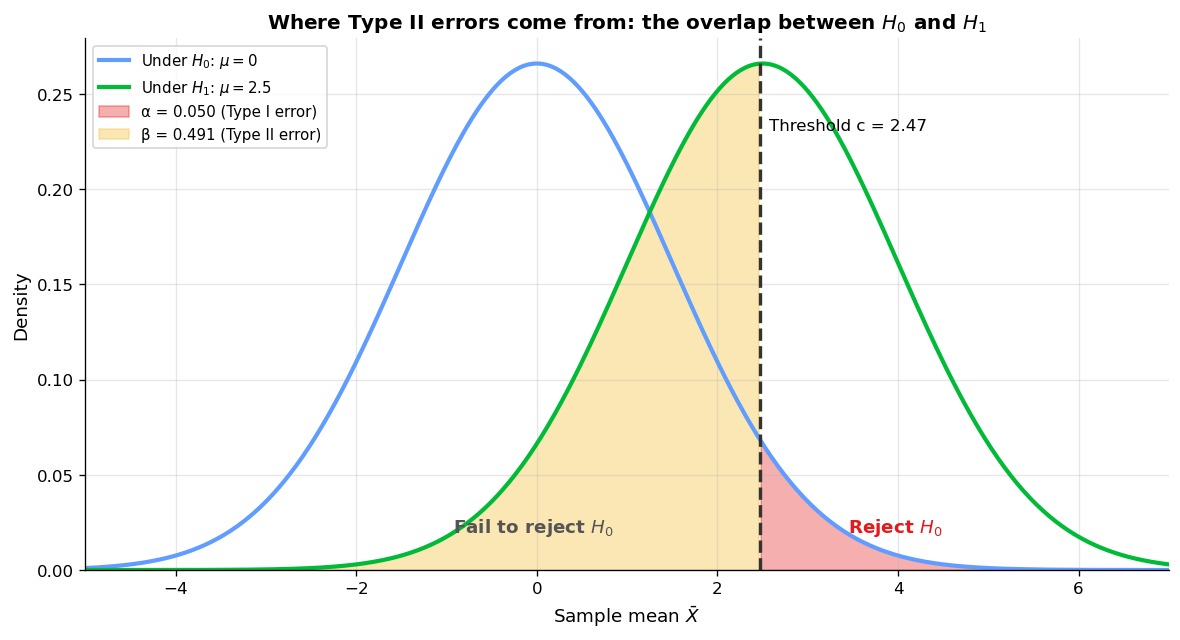

In [ ]:
# Visualising where false negatives (Type II errors) come from
fig, ax = plt.subplots(figsize=(10, 5.5))

mu_0_vis, mu_1_vis = 0, 2.5
sigma_vis = 1.5
alpha_vis = 0.05
c_vis = (
    mu_0_vis + stats.norm.ppf(1 - alpha_vis) * sigma_vis
)  # right-sided critical value

x_vis = np.linspace(-5, 7, 500)
pdf_null = stats.norm(mu_0_vis, sigma_vis).pdf(x_vis)
pdf_alt = stats.norm(mu_1_vis, sigma_vis).pdf(x_vis)

# Plot both distributions
ax.plot(
    x_vis,
    pdf_null,
    color="#619CFF",
    linewidth=2.5,
    label=f"Under $H_0$: $\mu = {mu_0_vis}$",
)
ax.plot(
    x_vis,
    pdf_alt,
    color="#00BA38",
    linewidth=2.5,
    label=f"Under $H_1$: $\mu = {mu_1_vis}$",
)

# Shade alpha (Type I error region under H0)
mask_alpha = x_vis >= c_vis
ax.fill_between(
    x_vis,
    pdf_null,
    where=mask_alpha,
    color="#E41A1C",
    alpha=0.35,
    label=f"α = {stats.norm(mu_0_vis, sigma_vis).sf(c_vis):.3f} (Type I error)",
)

# Shade beta (Type II error region under H1)
mask_beta = x_vis <= c_vis
ax.fill_between(
    x_vis,
    pdf_alt,
    where=mask_beta,
    color="#F4C542",
    alpha=0.4,
    label=f"β = {stats.norm(mu_1_vis, sigma_vis).cdf(c_vis):.3f} (Type II error)",
)

# Decision threshold
ax.axvline(c_vis, color="#333333", linewidth=2, linestyle="--")
ax.text(
    c_vis + 0.1,
    ax.get_ylim()[1] * 0.85,
    f"Threshold c = {c_vis:.2f}",
    fontsize=10,
    ha="left",
    va="top",
)

# Annotations
ax.annotate(
    "Reject $H_0$",
    xy=(c_vis + 1.5, 0.02),
    fontsize=11,
    ha="center",
    color="#E41A1C",
    fontweight="bold",
)
ax.annotate(
    "Fail to reject $H_0$",
    xy=(c_vis - 2.5, 0.02),
    fontsize=11,
    ha="center",
    color="#555555",
    fontweight="bold",
)

ax.set_xlabel(r"Sample mean $\bar{X}$", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    "Where Type II errors come from: the overlap between $H_0$ and $H_1$",
    fontsize=12,
    fontweight="bold",
)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(-5, 7)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

The gold region is the probability of a false negative ($eta$): the test fails to reject $H_0$ even though the data actually comes from $H_1$.

**Real-world consequences of each error type depend on context:**

| Context               | Type I error (false positive)                                      | Type II error (false negative)                                |
|-----------------------|--------------------------------------------------------------------|---------------------------------------------------------------|
| **Drug approval**     | Approve an ineffective drug — patients receive useless treatment   | Reject an effective drug — patients miss a beneficial therapy |
| **Quality control**   | Flag a compliant batch — unnecessary re-inspection costs           | Miss a defective batch — faulty products reach customers      |
| **Criminal trial**    | Convict an innocent person                                         | Acquit a guilty person                                        |
| **Medical screening** | Healthy patient told they are sick — unnecessary anxiety and tests | Sick patient told they are healthy — delayed treatment        |

In pharmaceutical trials, regulators typically set $lpha = 0.05$ or even $lpha = 0.01$ because approving an ineffective drug (Type I) can be very costly. In manufacturing, a small $lpha$ means fewer false alarms but a higher chance of missing defects — so the right $lpha$ depends on whether false alarms or missed defects are more expensive.

**The choice of $lpha$ is always a judgement call, informed by the costs and consequences in your specific domain.**

---

## 4. The $\alpha$-$\beta$ Tradeoff

Here is the fundamental tension: **reducing $\alpha$ increases $\beta$, and vice versa**. You cannot minimise both simultaneously (unless you collect more data).

Why? Imagine the null distribution ($H_0$ true) and the alternative distribution ($H_1$ true) overlap. The decision threshold divides the number line into a rejection region and a non-rejection region.

- **Moving the threshold to the right** (more conservative, smaller $\alpha$): The rejection region shrinks, so fewer false alarms — but more of the alternative distribution falls in the non-rejection region, increasing $\beta$.
- **Moving the threshold to the left** (more liberal, larger $\alpha$): More of the alternative distribution is captured — lower $\beta$, higher power — but more of the null distribution spills into the rejection region, increasing $\alpha$.

The only way to reduce **both** errors simultaneously is to make the two distributions overlap less, which happens when:
- The effect size is larger (distributions are farther apart)
- The sample size is larger (distributions are narrower)
- The variability is smaller (distributions are narrower)

Let's visualise this.

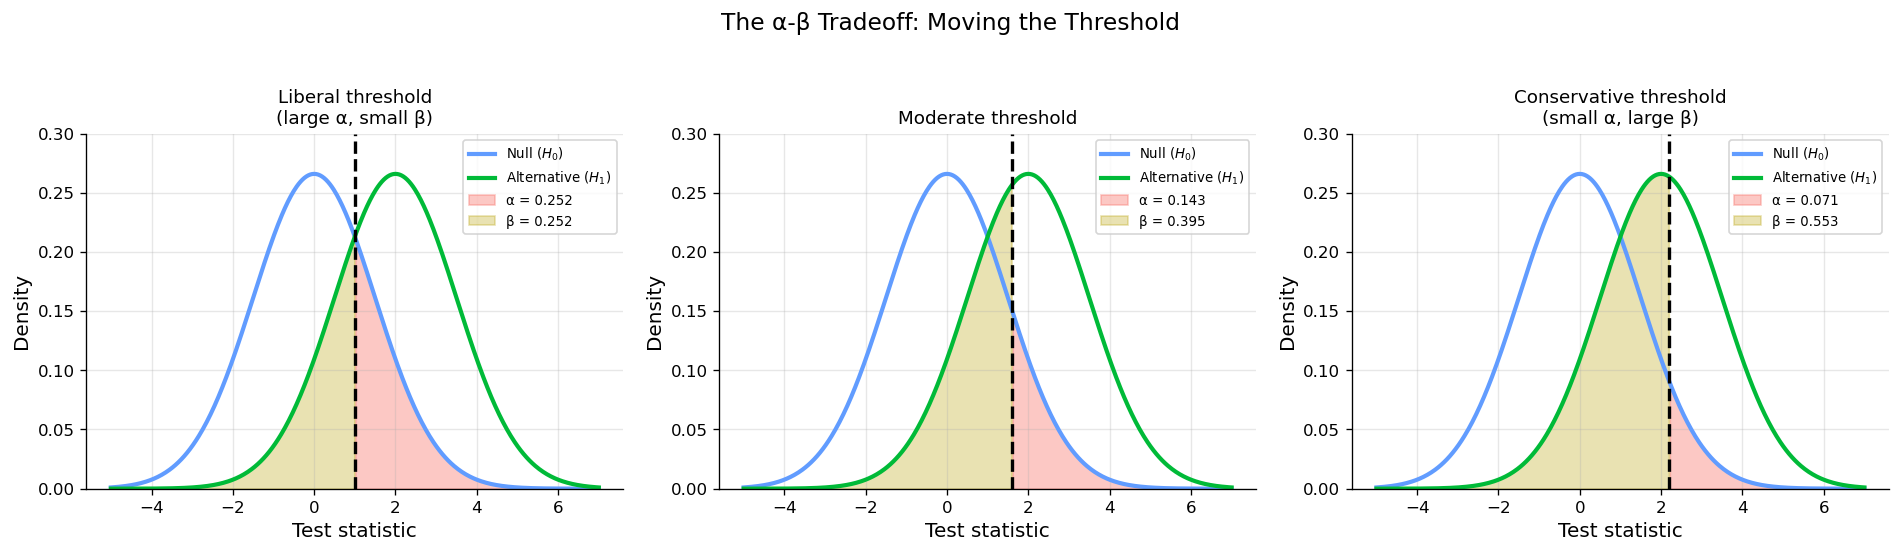

In [ ]:
# Visualise the alpha-beta tradeoff: two overlapping distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

mu_0, mu_1, sigma = 0, 2, 1.5
x = np.linspace(-5, 7, 500)
pdf_null = stats.norm(mu_0, sigma).pdf(x)
pdf_alt = stats.norm(mu_1, sigma).pdf(x)

thresholds = [1.0, 1.6, 2.2]  # different decision boundaries
titles = [
    "Liberal threshold\n(large α, small β)",
    "Moderate threshold",
    "Conservative threshold\n(small α, large β)",
]

for ax, c_val, title in zip(axes, thresholds, titles):
    # Plot both distributions
    ax.plot(x, pdf_null, color="#619CFF", linewidth=2.5, label="Null ($H_0$)")
    ax.plot(x, pdf_alt, color="#00BA38", linewidth=2.5, label="Alternative ($H_1$)")

    # Shade α region (null, right of threshold)
    mask_alpha = x >= c_val
    ax.fill_between(
        x[mask_alpha],
        pdf_null[mask_alpha],
        color="#F8766D",
        alpha=0.4,
        label=f"α = {1 - stats.norm(mu_0, sigma).cdf(c_val):.3f}",
    )

    # Shade β region (alternative, left of threshold)
    mask_beta = x <= c_val
    ax.fill_between(
        x[mask_beta],
        pdf_alt[mask_beta],
        color="#B79F00",
        alpha=0.3,
        label=f"β = {stats.norm(mu_1, sigma).cdf(c_val):.3f}",
    )

    # Threshold line
    ax.axvline(c_val, color="black", linewidth=2, linestyle="--")
    ax.set_xlabel("Test statistic")
    ax.set_ylabel("Density")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(0, 0.3)

plt.suptitle("The α-β Tradeoff: Moving the Threshold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The red-shaded area ($\alpha$) is the probability of a false alarm under $H_0$. The gold-shaded area ($\beta$) is the probability of missing the real effect under $H_1$. As the threshold moves right, $\alpha$ shrinks but $\beta$ grows. There is no free lunch — unless you collect more data to shrink both distributions.

---

## 5. Statistical Power: $1 - \beta$

> **Definition.** The **power** of a test is the probability of correctly rejecting $H_0$ when it is false:
>
> $$\text{Power} = 1 - \beta = P(\text{reject } H_0 \mid H_0 \text{ is false})$$

Power is the probability of **detecting a real effect**. A powerful test rarely misses real effects; a weak test frequently does.

In the fire alarm analogy, power is the probability that the alarm correctly sounds when there actually is a fire. You want this to be high.

### The conventional target

The widely accepted minimum is **power $\geq 0.80$** (80%). This means you accept at most a 20% chance of missing a real effect of the specified size. Many fields now recommend 0.90 or higher for confirmatory studies.

### What determines power?

Power depends on four quantities — understanding each is crucial:

| Factor                                     | Effect on power                             | Intuition                                                                              |
|--------------------------------------------|---------------------------------------------|----------------------------------------------------------------------------------------|
| **Effect size** ($\delta = \mu_1 - \mu_0$) | Larger $\delta$ $\Rightarrow$ higher power  | A big signal is easy to detect                                                         |
| **Sample size** ($n$)                      | Larger $n$ $\Rightarrow$ higher power       | More data $\Rightarrow$ narrower sampling distribution $\Rightarrow$ less overlap      |
| **Significance level** ($\alpha$)          | Larger $\alpha$ $\Rightarrow$ higher power  | More lenient threshold catches more of the alternative — but also more false positives |
| **Population variability** ($\sigma$)      | Smaller $\sigma$ $\Rightarrow$ higher power | Less noise $\Rightarrow$ signal stands out more                                        |

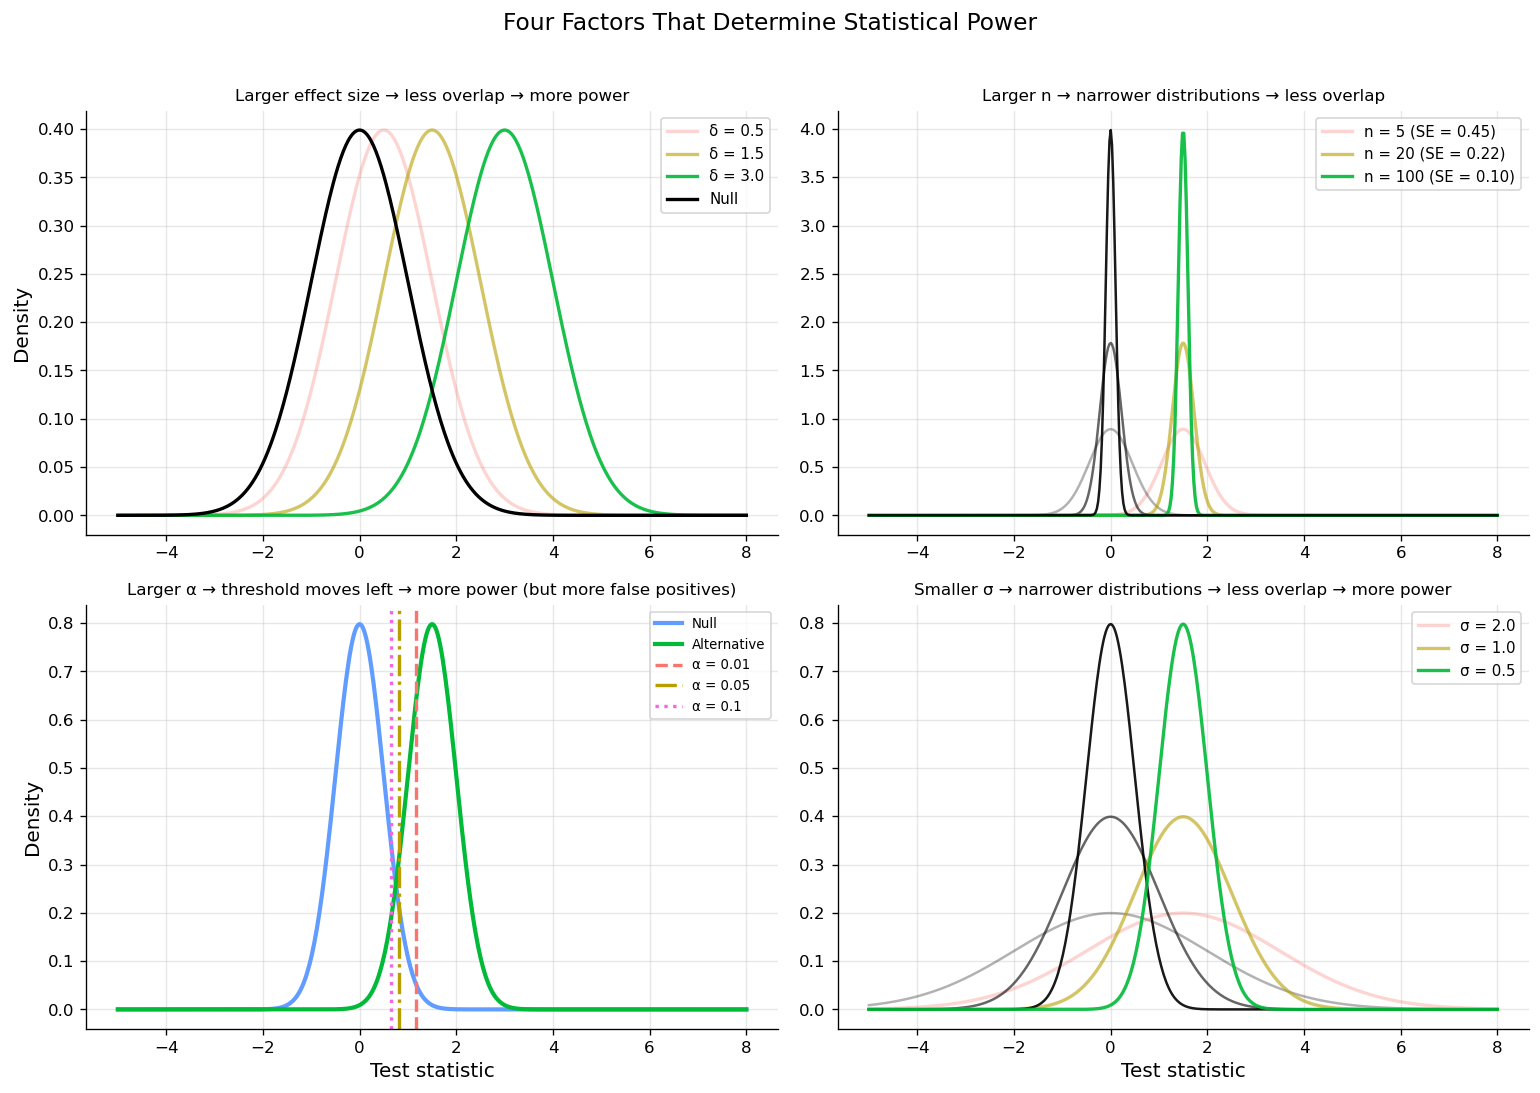

In [ ]:
# Visualise how each factor affects the overlap between H₀ and H₁
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

x = np.linspace(-5, 8, 500)

# Panel 1: Effect size
ax = axes[0, 0]
sigma_ref = 1.0
for delta, alpha_val in [(0.5, 0.3), (1.5, 0.6), (3.0, 0.9)]:
    pdf_a = stats.norm(delta, sigma_ref).pdf(x)
    ax.plot(x, pdf_a, linewidth=2, alpha=alpha_val, label=f"δ = {delta}")
ax.plot(x, stats.norm(0, sigma_ref).pdf(x), "k-", linewidth=2, label="Null")
ax.set_title("Larger effect size → less overlap → more power", fontsize=10)
ax.legend(fontsize=9)
ax.set_ylabel("Density")

# Panel 2: Sample size (affects SE = σ/√n)
ax = axes[0, 1]
delta_ref = 1.5
for n_val, alpha_val in [(5, 0.3), (20, 0.6), (100, 0.9)]:
    se = 1.0 / np.sqrt(n_val)
    ax.plot(
        x,
        stats.norm(delta_ref, se).pdf(x),
        linewidth=2,
        alpha=alpha_val,
        label=f"n = {n_val} (SE = {se:.2f})",
    )
    ax.plot(x, stats.norm(0, se).pdf(x), "k-", linewidth=1.5, alpha=alpha_val)
ax.set_title("Larger n → narrower distributions → less overlap", fontsize=10)
ax.legend(fontsize=9)

# Panel 3: Significance level α
ax = axes[1, 0]
se_ref = 0.5
pdf_null_ref = stats.norm(0, se_ref).pdf(x)
pdf_alt_ref = stats.norm(1.5, se_ref).pdf(x)
ax.plot(x, pdf_null_ref, color="#619CFF", linewidth=2.5, label="Null")
ax.plot(x, pdf_alt_ref, color="#00BA38", linewidth=2.5, label="Alternative")
for alpha_choice, col, ls in [
    (0.01, "#F8766D", "--"),
    (0.05, "#B79F00", "-."),
    (0.10, "#F564E3", ":"),
]:
    c_val = stats.norm(0, se_ref).ppf(1 - alpha_choice)
    ax.axvline(c_val, color=col, linewidth=2, linestyle=ls, label=f"α = {alpha_choice}")
ax.set_title(
    "Larger α → threshold moves left → more power (but more false positives)",
    fontsize=10,
)
ax.set_ylabel("Density")
ax.set_xlabel("Test statistic")
ax.legend(fontsize=8)

# Panel 4: Population variability σ
ax = axes[1, 1]
for sig_val, alpha_val in [(2.0, 0.3), (1.0, 0.6), (0.5, 0.9)]:
    ax.plot(x, stats.norm(0, sig_val).pdf(x), "k-", linewidth=1.5, alpha=alpha_val)
    ax.plot(
        x,
        stats.norm(1.5, sig_val).pdf(x),
        linewidth=2,
        alpha=alpha_val,
        label=f"σ = {sig_val}",
    )
ax.set_title(
    "Smaller σ → narrower distributions → less overlap → more power", fontsize=10
)
ax.set_xlabel("Test statistic")
ax.legend(fontsize=9)

plt.suptitle("Four Factors That Determine Statistical Power", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Each panel shows that power increases when the null and alternative distributions overlap less. The four levers — effect size, sample size, significance level, and population variability — all work by changing the degree of overlap.

---

## 6. Power Analysis from Scratch: The One-Sample Z-Test

Let's derive the power formula for the simplest case: a **one-sided, one-sample z-test** with known $\sigma$.

### Setup

- $H_0: \mu = \mu_0$ vs. $H_1: \mu > \mu_0$ (one-sided, upper tail)
- Data: $X_1, \dots, X_n \sim \mathcal{N}(\mu, \sigma^2)$ with $\sigma$ known.
- Test statistic: $Z = \dfrac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}$
- Decision rule: reject $H_0$ if $Z > z_{\alpha}$ (the upper $\alpha$-quantile of the standard Normal).

### Derivation

We want $\text{Power}(\mu_{\text{true}}) = P(\text{reject } H_0 \mid \mu = \mu_{\text{true}})$.

Under $H_1$, the true mean is $\mu_{\text{true}} \neq \mu_0$. The test statistic becomes:

$$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}$$

Under the true distribution, $\bar{X} \sim \mathcal{N}(\mu_{\text{true}}, \sigma^2/n)$, so:

$$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}} \sim \mathcal{N}\!\left(\frac{\mu_{\text{true}} - \mu_0}{\sigma / \sqrt{n}},\; 1\right)$$

The quantity $\dfrac{\mu_{\text{true}} - \mu_0}{\sigma / \sqrt{n}}$ is called the **noncentrality parameter**. Let's call it $\lambda$:

$$\lambda = \frac{(\mu_{\text{true}} - \mu_0)\sqrt{n}}{\sigma}$$

So under $H_1$: $Z \sim \mathcal{N}(\lambda, 1)$.

Power is the probability that $Z > z_{\alpha}$:

$$\text{Power} = P(Z > z_{\alpha}) = 1 - \Phi(z_{\alpha} - \lambda)$$

where $\Phi$ is the standard Normal CDF.

### The power formula (one-sided z-test)

$$\boxed{\text{Power} = 1 - \Phi\!\left(z_{\alpha} - \frac{(\mu_{\text{true}} - \mu_0)\sqrt{n}}{\sigma}\right)}$$

For a **two-sided** test at level $\alpha$, the power is approximately:

$$\text{Power} \approx 1 - \Phi\!\left(z_{\alpha/2} - \frac{|\mu_{\text{true}} - \mu_0|\sqrt{n}}{\sigma}\right)$$

(The approximation ignores the small probability of rejecting in the wrong tail, which is negligible for any reasonable effect size.)

In [4]:
def power_z_test(mu_true, mu_0, sigma, n, alpha, alternative="two-sided"):
    """Compute the power of a one-sample z-test from scratch.

    Parameters
    ----------
    mu_true : float
        The true population mean (under the alternative).
    mu_0 : float
        The null hypothesis mean.
    sigma : float
        Known population standard deviation.
    n : int or float
        Sample size.
    alpha : float
        Significance level.
    alternative : str
        'two-sided', 'greater', or 'less'.

    Returns
    -------
    float
        Power = P(reject H₀ | μ = mu_true).
    """
    # Noncentrality parameter
    lam = (mu_true - mu_0) * np.sqrt(n) / sigma

    if alternative == "greater":
        z_crit = stats.norm.ppf(1 - alpha)
        power = 1 - stats.norm.cdf(z_crit - lam)
    elif alternative == "less":
        z_crit = stats.norm.ppf(alpha)  # negative
        power = stats.norm.cdf(z_crit - lam)
    else:  # two-sided
        z_crit = stats.norm.ppf(1 - alpha / 2)
        # Probability of rejecting in the upper tail + lower tail
        power = (1 - stats.norm.cdf(z_crit - lam)) + stats.norm.cdf(-z_crit - lam)

    return power


# Verify: when mu_true = mu_0, power should equal alpha (rejecting a true H₀)
print("Verification: power when H₀ is actually true (should equal α)")
print(f"  α = 0.05, power = {power_z_test(0, 0, 1, 50, 0.05):.4f}")
print(f"  α = 0.01, power = {power_z_test(0, 0, 1, 50, 0.01):.4f}")

# Example: detect a shift of 0.5 with σ = 1, n = 50, α = 0.05
pw = power_z_test(mu_true=0.5, mu_0=0, sigma=1, n=50, alpha=0.05)
print(f"\nPower to detect μ = 0.5 (σ = 1, n = 50, α = 0.05): {pw:.4f}")
print(f"  → {pw:.0%} chance of detecting this effect")
print(f"  → {1 - pw:.0%} chance of missing it (Type II error β = {1 - pw:.4f})")

Verification: power when H₀ is actually true (should equal α)
  α = 0.05, power = 0.0500
  α = 0.01, power = 0.0100

Power to detect μ = 0.5 (σ = 1, n = 50, α = 0.05): 0.9424
  → 94% chance of detecting this effect
  → 6% chance of missing it (Type II error β = 0.0576)


When $\mu_{\text{true}} = \mu_0$, there is no effect to detect, so the "power" equals $\alpha$ — it's just the false positive rate. As the true mean moves away from $\mu_0$, power increases.

### Monte Carlo verification

Let's verify our analytical formula by simulation. We'll generate thousands of datasets under the alternative, run the z-test on each, and check that the empirical rejection rate matches our formula.

In [5]:
# Monte Carlo verification of the power formula
mu_true, mu_0, sigma, n, alpha = 0.5, 0.0, 1.0, 50, 0.05
n_sim = 50_000

rejections = 0
for _ in range(n_sim):
    sample = rng.normal(mu_true, sigma, n)
    z = (sample.mean() - mu_0) / (sigma / np.sqrt(n))
    p_val = 2 * stats.norm.sf(abs(z))  # two-sided
    if p_val < alpha:
        rejections += 1

empirical_power = rejections / n_sim
analytical_power = power_z_test(mu_true, mu_0, sigma, n, alpha)

print(f"Analytical power:  {analytical_power:.4f}")
print(f"Empirical power:   {empirical_power:.4f}  ({n_sim:,} simulations)")
print(f"Difference:        {abs(analytical_power - empirical_power):.4f}")

Analytical power:  0.9424
Empirical power:   0.9437  (50,000 simulations)
Difference:        0.0013


The analytical and empirical power match closely — our formula is correct.

---

## 7. Power Curves

A **power curve** (or power function) plots power against one of the factors that determines it, holding the others fixed. These curves are the single most useful tool for understanding what your test can and cannot detect.

### Power vs. effect size (for different $n$)

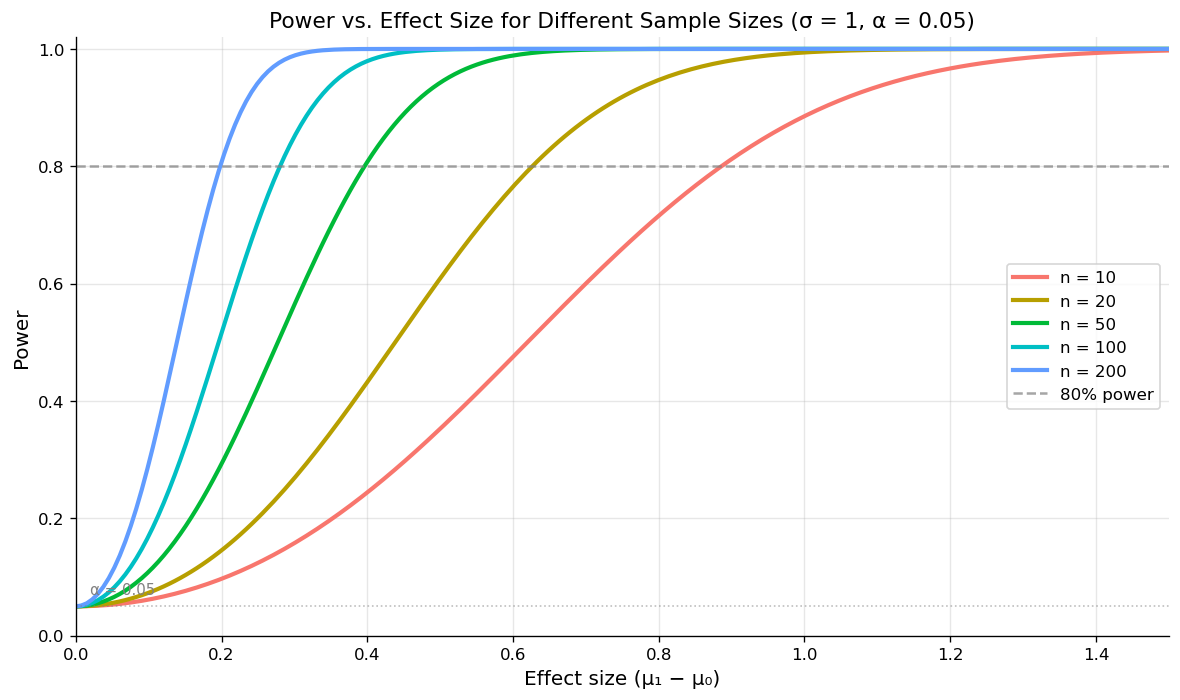

In [ ]:
# Power vs. effect size for different sample sizes
fig, ax = plt.subplots(figsize=(10, 6))

effect_sizes = np.linspace(0, 1.5, 200)
sigma, alpha = 1.0, 0.05

sample_sizes = [10, 20, 50, 100, 200]
colors = ["#F8766D", "#B79F00", "#00BA38", "#00BFC4", "#619CFF"]

for n_val, col in zip(sample_sizes, colors):
    powers = [power_z_test(d, 0, sigma, n_val, alpha) for d in effect_sizes]
    ax.plot(effect_sizes, powers, linewidth=2.5, color=col, label=f"n = {n_val}")

ax.axhline(
    0.80, color="grey", linewidth=1.5, linestyle="--", alpha=0.7, label="80% power"
)
ax.axhline(alpha, color="grey", linewidth=1, linestyle=":", alpha=0.5)
ax.text(0.02, alpha + 0.02, f"α = {alpha}", fontsize=9, color="grey")

ax.set_xlabel("Effect size (μ₁ − μ₀)", fontsize=12)
ax.set_ylabel("Power", fontsize=12)
ax.set_title(
    "Power vs. Effect Size for Different Sample Sizes (σ = 1, α = 0.05)", fontsize=13
)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 1.5)
plt.tight_layout()
plt.show()

Key observations:

- **All curves start at $\alpha = 0.05$** when effect size is zero (no real effect to detect).
- **All curves approach 1** as the effect size grows (large effects are always detectable).
- **Larger $n$ curves rise faster** — more data makes smaller effects detectable.
- To detect an effect of size 0.5 with 80% power, you need roughly $n = 50$. For effect size 0.3, you need about $n = 100$.

### Power vs. sample size $n$ (for different effect sizes)

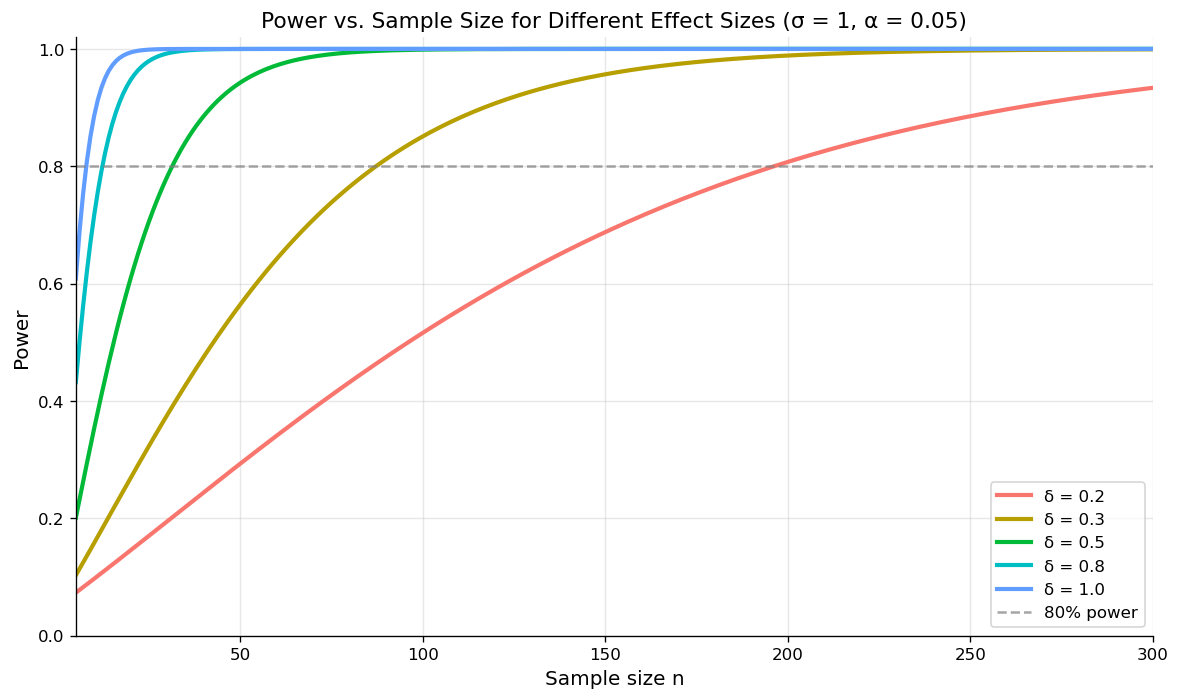

In [ ]:
# Power vs. sample size for different effect sizes
fig, ax = plt.subplots(figsize=(10, 6))

n_values = np.arange(5, 301)
sigma, alpha = 1.0, 0.05

effect_sizes_fixed = [0.2, 0.3, 0.5, 0.8, 1.0]

for d, col in zip(effect_sizes_fixed, colors):
    powers = [power_z_test(d, 0, sigma, n_val, alpha) for n_val in n_values]
    ax.plot(n_values, powers, linewidth=2.5, color=col, label=f"δ = {d}")

ax.axhline(
    0.80, color="grey", linewidth=1.5, linestyle="--", alpha=0.7, label="80% power"
)

ax.set_xlabel("Sample size n", fontsize=12)
ax.set_ylabel("Power", fontsize=12)
ax.set_title(
    "Power vs. Sample Size for Different Effect Sizes (σ = 1, α = 0.05)", fontsize=13
)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.02)
ax.set_xlim(5, 300)
plt.tight_layout()
plt.show()

This plot answers the practical question: **how many subjects do I need?** Find the effect size you care about, then read across to 80% power. For example:

- $\delta = 0.2$ (small): you need $n \approx 200$ — small effects are expensive to detect.
- $\delta = 0.5$ (medium): you need $n \approx 30$.
- $\delta = 0.8$ (large): you need $n \approx 15$.

This is why **power analysis before collecting data** is so important: it prevents you from running underpowered studies that are likely to miss real effects.

---

## 8. Manim Animation: The $\alpha$-$\beta$ Tradeoff

The animation below shows two overlapping Normal distributions — the null ($H_0$: $\mu = \mu_0$) and the alternative ($H_1$: $\mu = \mu_1$). A vertical threshold line slides from left to right. Watch how the $\alpha$ region (under the null curve, right of the threshold) and the $\beta$ region (under the alternative curve, left of the threshold) change as the threshold moves.

In [8]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C

Manim Community v0.18.1

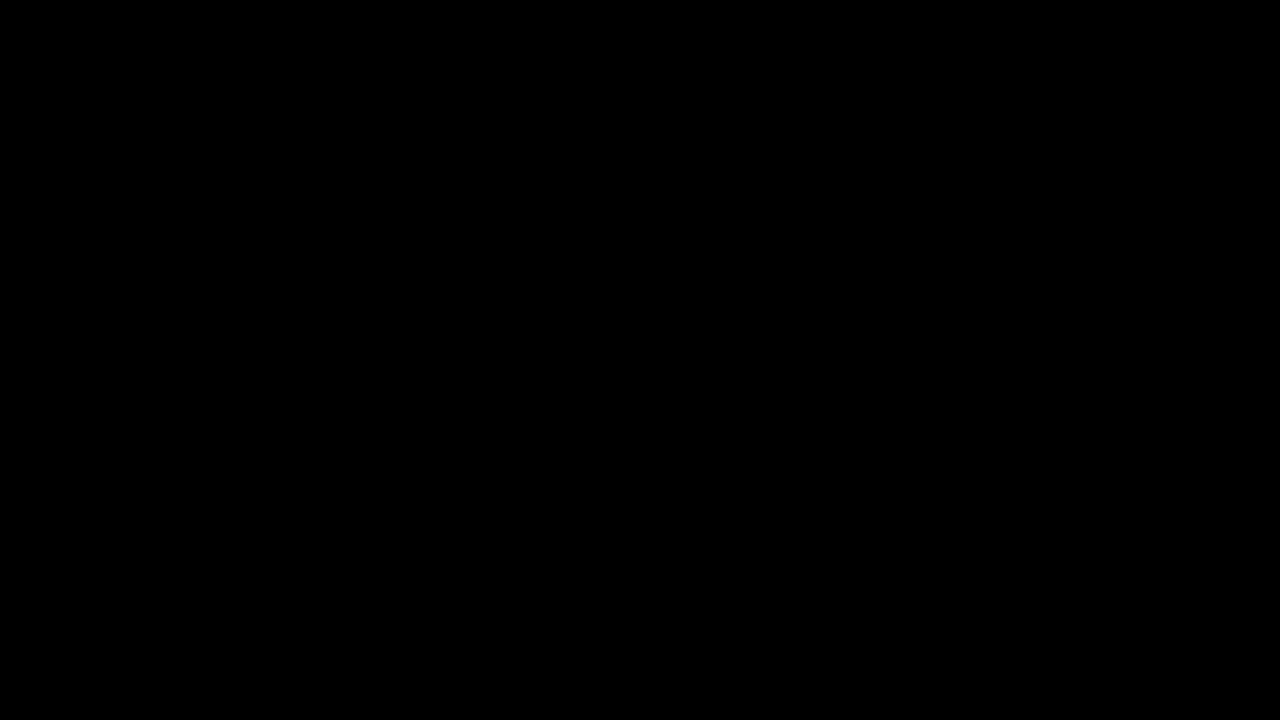

In [ ]:
%%manim -qm -v WARNING AlphaBetaTradeoff


class AlphaBetaTradeoff(Scene):
    """Animate the α-β tradeoff by sliding a decision threshold."""

    def construct(self):
        # ── Parameters ──
        mu_0, mu_1, sigma = 0.0, 2.5, 1.0
        x_min, x_max = -4, 7

        # ── Title ──
        title = Text("The α–β Tradeoff", font_size=30).to_edge(UP)
        self.play(Write(title), run_time=0.8)

        # ── Axes ──
        axes = Axes(
            x_range=[x_min, x_max, 1],
            y_range=[0, 0.5, 0.1],
            x_length=10,
            y_length=4.5,
            axis_config={"include_numbers": True, "font_size": 18},
        ).shift(DOWN * 0.3)
        self.play(Create(axes), run_time=0.6)

        # ── Null and alternative curves ──
        null_curve = axes.plot(
            lambda x: stats.norm(mu_0, sigma).pdf(x),
            x_range=[x_min, x_max],
            color=C.PERIWINKLE,
            stroke_width=3,
        )
        alt_curve = axes.plot(
            lambda x: stats.norm(mu_1, sigma).pdf(x),
            x_range=[x_min, x_max],
            color=C.EMERALD,
            stroke_width=3,
        )

        null_label = Text("H₀", font_size=22, color=C.PERIWINKLE).next_to(
            axes.c2p(mu_0, stats.norm(mu_0, sigma).pdf(mu_0)), UP, buff=0.15
        )
        alt_label = Text("H₁", font_size=22, color=C.EMERALD).next_to(
            axes.c2p(mu_1, stats.norm(mu_1, sigma).pdf(mu_1)), UP, buff=0.15
        )

        self.play(
            Create(null_curve),
            Create(alt_curve),
            Write(null_label),
            Write(alt_label),
            run_time=1,
        )
        self.wait(0.5)

        # ── Threshold line (ValueTracker) ──
        threshold = ValueTracker(0.5)  # starting position

        threshold_line = always_redraw(
            lambda: DashedLine(
                axes.c2p(threshold.get_value(), 0),
                axes.c2p(threshold.get_value(), 0.45),
                color=C.GOLD,
                stroke_width=3,
            )
        )

        # ── α region: null curve, RIGHT of threshold ──
        def get_alpha_region():
            t = threshold.get_value()
            x_vals = np.linspace(t, x_max, 200)
            points = [axes.c2p(xv, stats.norm(mu_0, sigma).pdf(xv)) for xv in x_vals]
            points.append(axes.c2p(x_max, 0))
            points.append(axes.c2p(t, 0))
            poly = Polygon(
                *points,
                fill_color=C.SALMON,
                fill_opacity=0.45,
                stroke_width=0,
            )
            return poly

        alpha_region = always_redraw(get_alpha_region)

        # ── β region: alternative curve, LEFT of threshold ──
        def get_beta_region():
            t = threshold.get_value()
            x_vals = np.linspace(x_min, t, 200)
            points = [axes.c2p(xv, stats.norm(mu_1, sigma).pdf(xv)) for xv in x_vals]
            points.append(axes.c2p(t, 0))
            points.append(axes.c2p(x_min, 0))
            poly = Polygon(
                *points,
                fill_color=C.PERIWINKLE,
                fill_opacity=0.3,
                stroke_width=0,
            )
            return poly

        beta_region = always_redraw(get_beta_region)

        # ── Dynamic labels showing α and β values ──
        def get_alpha_label():
            t = threshold.get_value()
            a_val = 1 - stats.norm(mu_0, sigma).cdf(t)
            return (
                Text(f"α = {a_val:.3f}", font_size=22, color=C.SALMON)
                .to_corner(UR)
                .shift(DOWN * 0.8)
            )

        def get_beta_label():
            t = threshold.get_value()
            b_val = stats.norm(mu_1, sigma).cdf(t)
            return (
                Text(f"β = {b_val:.3f}", font_size=22, color=C.PERIWINKLE)
                .to_corner(UR)
                .shift(DOWN * 1.4)
            )

        def get_power_label():
            t = threshold.get_value()
            b_val = stats.norm(mu_1, sigma).cdf(t)
            return (
                Text(f"Power = {1 - b_val:.3f}", font_size=22, color=C.EMERALD)
                .to_corner(UR)
                .shift(DOWN * 2.0)
            )

        alpha_label = always_redraw(get_alpha_label)
        beta_label = always_redraw(get_beta_label)
        power_label = always_redraw(get_power_label)

        self.play(
            FadeIn(threshold_line),
            FadeIn(alpha_region),
            FadeIn(beta_region),
            FadeIn(alpha_label),
            FadeIn(beta_label),
            FadeIn(power_label),
            run_time=0.8,
        )
        self.wait(0.5)

        # ── Slide threshold from left to right ──
        # Start conservative (far right) → move liberal (left) → back to moderate
        self.play(threshold.animate.set_value(3.0), run_time=3, rate_func=smooth)
        self.wait(0.5)
        self.play(threshold.animate.set_value(-0.5), run_time=4, rate_func=smooth)
        self.wait(0.5)
        self.play(threshold.animate.set_value(1.65), run_time=3, rate_func=smooth)
        self.wait(1.5)

Watch the numbers in the top-right corner. As the threshold slides right (more conservative), $\alpha$ shrinks toward zero but $\beta$ balloons — you almost never get a false alarm, but you miss most real effects. As the threshold slides left (more liberal), $\beta$ shrinks and power approaches 1, but $\alpha$ grows — you detect everything, including noise. The optimal threshold balances these competing demands.

---

## 9. Sample Size Calculation

One of the most practical applications of power analysis: **how many observations do I need?**

### Derivation

Starting from the two-sided power formula:

$$\text{Power} = \Phi\!\left(\frac{|\mu_{\text{true}} - \mu_0| \sqrt{n}}{\sigma} - z_{\alpha/2}\right)$$

We want $\text{Power} = 1 - \beta$, so we need:

$$1 - \beta = \Phi\!\left(\frac{\delta \sqrt{n}}{\sigma} - z_{\alpha/2}\right)$$

where $\delta = |\mu_{\text{true}} - \mu_0|$ is the minimum detectable effect size. Applying $\Phi^{-1}$ to both sides:

$$z_{1-\beta} = \frac{\delta \sqrt{n}}{\sigma} - z_{\alpha/2}$$

Note: $z_{1-\beta} = \Phi^{-1}(1-\beta) = -z_{\beta}$. Since $\Phi^{-1}(0.8) \approx 0.842$ for 80% power.

Solving for $n$:

$$\sqrt{n} = \frac{(z_{\alpha/2} + z_{1-\beta})\,\sigma}{\delta}$$

$$\boxed{n = \left(\frac{(z_{\alpha/2} + z_{1-\beta})\,\sigma}{\delta}\right)^{\!2}}$$

This is the **sample size formula for a one-sample z-test**. Let's implement it.

In [ ]:
def sample_size_z_test(delta, sigma, alpha=0.05, power=0.80, alternative="two-sided"):
    """Compute the required sample size for a one-sample z-test.

    Parameters
    ----------
    delta : float
        Minimum detectable effect size |μ₁ - μ₀|.
    sigma : float
        Known population standard deviation.
    alpha : float
        Significance level (default 0.05).
    power : float
        Desired power (default 0.80).
    alternative : str
        'two-sided' or 'one-sided'.

    Returns
    -------
    int
        Required sample size (rounded up).
    """
    z_beta = stats.norm.ppf(power)  # z_{1-β}, e.g. 0.842 for 80% power
    if alternative == "two-sided":
        z_alpha = stats.norm.ppf(1 - alpha / 2)  # z_{α/2}
    else:
        z_alpha = stats.norm.ppf(1 - alpha)

    n = ((z_alpha + z_beta) * sigma / delta) ** 2
    return int(np.ceil(n))  # always round up


# Example: detect a shift of 0.5 with σ = 1, α = 0.05, power = 0.80
n_required = sample_size_z_test(delta=0.5, sigma=1.0, alpha=0.05, power=0.80)
print(f"To detect δ = 0.5 (σ = 1) with 80% power at α = 0.05:")
print(f"  Required n = {n_required}")

# Verify
actual_power = power_z_test(0.5, 0, 1.0, n_required, 0.05)
print(f"  Actual power at n = {n_required}: {actual_power:.4f}")

print("\n--- Sample sizes for common scenarios ---")
for delta in [0.2, 0.3, 0.5, 0.8, 1.0]:
    n_req = sample_size_z_test(delta, sigma=1.0)
    print(f"  δ = {delta}, σ = 1.0  →  n = {n_req}")

To detect δ = 0.5 (σ = 1) with 80% power at α = 0.05:
  Required n = 32
  Actual power at n = 32: 0.8074

--- Sample sizes for common scenarios ---
  δ = 0.2, σ = 1.0  →  n = 197
  δ = 0.3, σ = 1.0  →  n = 88
  δ = 0.5, σ = 1.0  →  n = 32
  δ = 0.8, σ = 1.0  →  n = 13
  δ = 1.0, σ = 1.0  →  n = 8


Notice the **quadratic relationship**: halving the effect size quadruples the required sample size. Detecting small effects is expensive. This is why it's so important to decide *what effect size matters to you* before planning a study.

### Sample size as a function of desired power

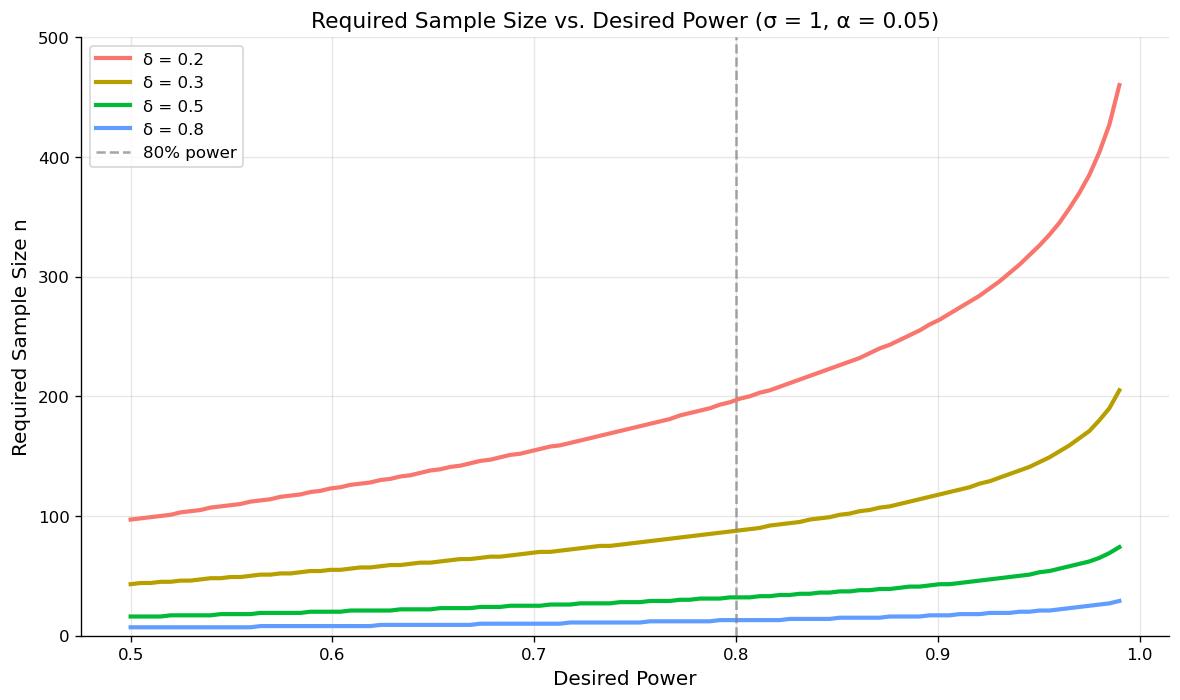

In [ ]:
# Sample size vs. desired power for different effect sizes
fig, ax = plt.subplots(figsize=(10, 6))

power_targets = np.linspace(0.50, 0.99, 100)

for d, col in zip([0.2, 0.3, 0.5, 0.8], ["#F8766D", "#B79F00", "#00BA38", "#619CFF"]):
    n_vals = [sample_size_z_test(d, sigma=1.0, power=pw) for pw in power_targets]
    ax.plot(power_targets, n_vals, linewidth=2.5, color=col, label=f"δ = {d}")

ax.axvline(
    0.80, color="grey", linewidth=1.5, linestyle="--", alpha=0.7, label="80% power"
)
ax.set_xlabel("Desired Power", fontsize=12)
ax.set_ylabel("Required Sample Size n", fontsize=12)
ax.set_title("Required Sample Size vs. Desired Power (σ = 1, α = 0.05)", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 500)
plt.tight_layout()
plt.show()

The required sample size explodes as you approach power $= 1$ (you can't be *certain* you'll detect a finite effect). For small effects ($\delta = 0.2$), even 80% power requires hundreds of observations.

---

## 10. Effect Size: Cohen's $d$

So far we've discussed the **raw** effect size $\delta = |\mu_1 - \mu_0|$, which is measured in the units of the data (mmHg, kg, dollars, etc.). This makes it hard to compare effect sizes across different studies or variables.

**Cohen's $d$** is a **standardised** effect size that divides the raw difference by the standard deviation:

> **Definition.** For a one-sample test comparing a mean $\bar{X}$ to a hypothesised value $\mu_0$:
>
> $$d = \frac{|\bar{X} - \mu_0|}{s}$$
>
> where $s$ is the sample standard deviation.

For two independent samples:

$$d = \frac{|\bar{X}_1 - \bar{X}_2|}{s_p}$$

where $s_p = \sqrt{\frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}}$ is the pooled standard deviation.

### Cohen's conventions

Jacob Cohen (1988) proposed rough guidelines for interpreting $d$:

| $d$ | Interpretation | Example                                 |
|-----|----------------|-----------------------------------------|
| 0.2 | **Small**      | Barely noticeable to a careful observer |
| 0.5 | **Medium**     | Noticeable to a naked eye               |
| 0.8 | **Large**      | Obvious and substantial                 |

**Caveat:** These are rough heuristics, not universal truths. In some fields (e.g., education), $d = 0.2$ is practically meaningful. In others (e.g., clinical trials for life-saving drugs), even $d = 0.1$ matters enormously. Always consider the **domain context** when interpreting effect sizes.

### The connection to power

Notice that our noncentrality parameter can be written in terms of Cohen's $d$:

$$\lambda = \frac{\delta \sqrt{n}}{\sigma} = d \sqrt{n}$$

This means power depends on $n$ and $d$ only through the product $d\sqrt{n}$. The power formula becomes:

$$\text{Power} = \Phi(d\sqrt{n} - z_{\alpha/2})$$

And the sample size formula:

$$n = \left(\frac{z_{\alpha/2} + z_{1-\beta}}{d}\right)^{\!2}$$

This is elegant: you only need to know $d$ (not $\delta$ and $\sigma$ separately) to compute power and required sample size.

In [ ]:
def cohens_d_one_sample(sample, mu_0):
    """Compute Cohen's d for a one-sample test."""
    return abs(sample.mean() - mu_0) / sample.std(ddof=1)


def cohens_d_two_sample(sample_1, sample_2):
    """Compute Cohen's d for an independent two-sample test (pooled SD)."""
    n1, n2 = len(sample_1), len(sample_2)
    s1, s2 = sample_1.std(ddof=1), sample_2.std(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return abs(sample_1.mean() - sample_2.mean()) / s_pooled


# Example: a drug trial
control = rng.normal(loc=120, scale=15, size=50)  # systolic BP, control group
treatment = rng.normal(loc=115, scale=15, size=50)  # treatment group (5 mmHg reduction)

d = cohens_d_two_sample(treatment, control)
print(f"Control:   mean = {control.mean():.1f}, sd = {control.std(ddof=1):.1f}")
print(f"Treatment: mean = {treatment.mean():.1f}, sd = {treatment.std(ddof=1):.1f}")
print(f"\nRaw effect: {abs(treatment.mean() - control.mean()):.1f} mmHg")
print(f"Cohen's d:  {d:.3f}")

if d < 0.2:
    label = "negligible"
elif d < 0.5:
    label = "small"
elif d < 0.8:
    label = "medium"
else:
    label = "large"
print(f"Interpretation: {label} effect (Cohen's conventions)")

Control:   mean = 118.9, sd = 17.2
Treatment: mean = 112.3, sd = 16.8

Raw effect: 6.6 mmHg
Cohen's d:  0.386
Interpretation: small effect (Cohen's conventions)


A 5 mmHg reduction in blood pressure with $\sigma \approx 15$ gives $d \approx 0.33$ — a small-to-medium effect by Cohen's conventions. Whether this is *clinically* meaningful depends on the medical context (for hypertension, even 3-5 mmHg reductions are associated with reduced cardiovascular risk).

---

## 11. Putting It All Together: A Complete Power Analysis

Let's walk through a realistic power analysis from start to finish.

**Scenario:** A psychologist wants to test whether a new study technique improves exam scores. Based on a pilot study, the expected improvement is about 5 points on a 100-point scale, and the standard deviation is about 15 points.

**Questions:**
1. What is Cohen's $d$ for this effect?
2. How many students are needed for 80% power at $\alpha = 0.05$?
3. What if we want 90% power instead?
4. What power would we have with only $n = 30$ students?

In [ ]:
# Complete power analysis example
delta = 5  # expected improvement (points)
sigma = 15  # population SD (points)
alpha = 0.05

# 1. Cohen's d
d = delta / sigma
print(f"1. Cohen's d = {delta}/{sigma} = {d:.3f} — a small effect")

# 2. Sample size for 80% power
n_80 = sample_size_z_test(delta, sigma, alpha=alpha, power=0.80)
print(f"\n2. Required n for 80% power: {n_80}")

# 3. Sample size for 90% power
n_90 = sample_size_z_test(delta, sigma, alpha=alpha, power=0.90)
print(f"   Required n for 90% power: {n_90}")
print(f"   (Going from 80% to 90% power costs {n_90 - n_80} extra participants)")

# 4. Power with n = 30
pw_30 = power_z_test(mu_true=delta, mu_0=0, sigma=sigma, n=30, alpha=alpha)
print(f"\n3. Power with n = 30: {pw_30:.3f} ({pw_30:.0%})")
print(f"   → There's a {1 - pw_30:.0%} chance of missing the effect!")
print(f"   → This study would be severely underpowered.")

1. Cohen's d = 5/15 = 0.333 — a small effect

2. Required n for 80% power: 71
   Required n for 90% power: 95
   (Going from 80% to 90% power costs 24 extra participants)

3. Power with n = 30: 0.447 (45%)
   → There's a 55% chance of missing the effect!
   → This study would be severely underpowered.


This analysis tells the psychologist: with only 30 students, there is a very high chance of concluding "the technique doesn't work" even if it actually improves scores by 5 points. They need substantially more participants to have a reasonable chance of detecting the effect. **Planning the sample size before collecting data is essential.**

---

## Exercises

**Exercise 3.1 (Identifying errors).** For each scenario, state whether a Type I or Type II error has occurred:

(a) A drug actually lowers cholesterol, but the clinical trial fails to detect the effect ($p = 0.12$).

(b) A coin is fair ($p = 0.5$), but after 200 flips you conclude it's biased ($p\text{-value} = 0.03$).

(c) A defendant is innocent, but the jury convicts them.

(d) A manufacturing process has shifted, but the control chart fails to trigger an alarm.

**Exercise 3.2 (Power computation).** A researcher plans a one-sample z-test to detect whether the mean IQ in a special program differs from 100. Assume $\sigma = 15$.

(a) Compute the power to detect $\mu = 105$ with $n = 25$ at $\alpha = 0.05$ (two-sided).

(b) What sample size is needed for 80% power to detect this 5-point difference?

(c) What sample size is needed for 80% power to detect a 3-point difference?

**Exercise 3.3 (Power curve).** Plot the power curve (power vs. $n$ from 5 to 500) for detecting $\mu = 103$ vs. $\mu_0 = 100$ with $\sigma = 15$ and $\alpha = 0.05$. At what $n$ does power first exceed 0.80?

**Exercise 3.4 (Effect of $\alpha$).** For $\delta = 0.5$, $\sigma = 1$, $n = 50$, compute the power at $\alpha = 0.10, 0.05, 0.01, 0.005, 0.001$. Plot power vs. $\alpha$. What happens to the Type II error rate when you demand very strong evidence (small $\alpha$)?

**Exercise 3.5 (Cohen's $d$).** Two groups of students take an exam. Group A ($n = 40$): $\bar{x}_A = 74.2$, $s_A = 11.3$. Group B ($n = 35$): $\bar{x}_B = 69.8$, $s_B = 12.1$. Compute Cohen's $d$ and interpret it. Was the study adequately powered to detect this effect at $\alpha = 0.05$ with 80% power?

**Exercise 3.6 (Challenge — simulation study).** Write a simulation that generates 10,000 datasets of size $n = 20$ from $\mathcal{N}(0.3, 1)$ (true effect = 0.3), runs a two-sided z-test on each ($H_0: \mu = 0$), and records the rejection rate. Compare the empirical power to the analytical power from `power_z_test()`. Then repeat for $n = 50$ and $n = 100$. What fraction of "real" effects does each sample size detect?

---

## Key Takeaways

1. **Type I error ($\alpha$):** Rejecting $H_0$ when it's true — a false alarm. Controlled directly by the significance level.
2. **Type II error ($\beta$):** Failing to reject $H_0$ when it's false — a missed detection. Harder to control because it depends on the unknown true effect.
3. **The tradeoff:** Reducing $\alpha$ increases $\beta$ and vice versa. The only way to reduce both is to collect more data or have a larger effect.
4. **Power $= 1 - \beta$:** The probability of detecting a real effect. Target at least 80%, preferably 90%.
5. **Four levers of power:** effect size ($\delta$), sample size ($n$), significance level ($\alpha$), and variability ($\sigma$).
6. **Sample size formula:** $n = \left(\frac{(z_{\alpha/2} + z_{1-\beta})\,\sigma}{\delta}\right)^{\!2}$ — halving the detectable effect quadruples the required $n$.
7. **Cohen's $d$:** Standardised effect size ($\delta / \sigma$). Small $\approx 0.2$, medium $\approx 0.5$, large $\approx 0.8$.
8. **Plan before you collect:** Power analysis determines $n$ before the study, preventing underpowered research that wastes resources and misses real effects.

**Next:** [04_multiple_testing.ipynb](04_multiple_testing.ipynb) — When you run many tests simultaneously, the false positive rate inflates dramatically. We'll explore the problem and its solutions: Bonferroni, Holm, and False Discovery Rate control.

In [14]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/AlphaBetaTradeoff@2026-03-19@17-42-26.gif
  ✓ media/gifs/AlphaBetaTradeoff_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
